# Intrinsic Properties Aggregation

Reads cell metadata from the VTA_diet Google Sheet, loads each cell's `cell_summary.json`,
and builds a cell × features table with diet information.

**To add or remove features:** edit `FEATURE_MAP` in Cell 1.  
Each entry maps a column name to a tuple of nested JSON keys, e.g.:
```python
'fi_slope_hz_per_pA': ('fi_curve', 'cell_level', 'fi_slope_hz_per_pA')
```
Missing sections return `NaN` automatically.

In [11]:
import json
import pandas as pd
from pathlib import Path
from matplotlib import pyplot as plt
import numpy as np

# ── Google Sheet ────────────────────────────────────────────────────────────
SPREADSHEET_ID = "1JHW5CJrUEmkd06TtWC34ATEWOTMBqQQtzxqw3yQ4OF0"

# ── Feature map ─────────────────────────────────────────────────────────────
# Keys are output column names; values are tuples of JSON keys to traverse.
# Any missing section or key returns NaN.
FEATURE_MAP = {
    # Resting membrane potential
    "v_rest_mV":              ("v_rest", "v_rest_mV"),

    # Passive properties (small-step average)
    "input_R_MOhm":           ("passive_repeated_step", "input_resistance_MOhm"),
    "membrane_tau_ms":        ("passive_repeated_step", "time_constant_ms"),
    "tau_r2":                 ("passive_repeated_step", "time_constant_r2"),
    "sag_ratio":              ("passive_repeated_step", "sag_ratio"),
    "sag_amplitude_mV":       ("passive_repeated_step", "sag_amplitude_mV"),
    "sag_tau_ms":             ("passive_repeated_step", "sag_tau_ms"),

    # FI curve
    "rheobase_pA":            ("fi_curve", "cell_level", "rheobase_pA"),
    "max_firing_rate_hz":     ("fi_curve", "cell_level", "max_firing_rate_hz"),
    "max_inst_firing_rate_hz":("fi_curve", "cell_level", "max_peak_instantaneous_rate_hz"),
    "fi_slope_hz_per_pA":     ("fi_curve", "cell_level", "fi_slope_hz_per_pA"),
    "fi_slope_r2":            ("fi_curve", "cell_level", "fi_slope_r2"),

    # Action potential shape (ramp-evoked, cell-level means)
    "ap_threshold_mV":        ("ramp_evoked_APs", "cell_level", "mean_threshold_voltage_mV"),
    "ap_peak_mV":             ("ramp_evoked_APs", "cell_level", "mean_peak_voltage_mV"),
    "ap_height_mV":           ("ramp_evoked_APs", "cell_level", "mean_height_mV"),
    "ap_half_width_ms":       ("ramp_evoked_APs", "cell_level", "mean_half_width_ms"),
    "ahp_depth_mV":           ("ramp_evoked_APs", "cell_level", "mean_ahp_depth_mV"),
    "ap_upstroke_mV_per_ms":  ("ramp_evoked_APs", "cell_level", "mean_upstroke_mVms"),
    "ap_downstroke_mV_per_ms":("ramp_evoked_APs", "cell_level", "mean_downstroke_mVms"),
    "rheobase_ramp_pA":       ("ramp_evoked_APs", "cell_level", "mean_current_at_threshold_pA"),
    
}

In [2]:
# ── Load Google Sheet tabs ───────────────────────────────────────────────────
# Downloads the workbook as xlsx so each sheet is selected by name,
# avoiding the redirect caching issue with the CSV export endpoint.
xlsx_url = f"https://docs.google.com/spreadsheet/ccc?key={SPREADSHEET_ID}&output=xlsx"

intrinsic_df = pd.read_excel(xlsx_url, sheet_name="intrinsic")
animal_df    = pd.read_excel(xlsx_url, sheet_name="animal")

df = intrinsic_df.merge(animal_df, on="animal_id", how="left")
print(f"{len(df)} cells loaded")
df

42 cells loaded


,cell_id,animal_id,folder_path,cell_summary_json,notes,animal_diet
0,20260506_cell1_TH,m260506,C:\Users\tahage\Box\CreedLabBoxDrive\VTA_obesi...,C:\Users\tahage\Box\CreedLabBoxDrive\VTA_obesi...,NaN,chow
1,20260506_cell2_TH,m260506,C:\Users\tahage\Box\CreedLabBoxDrive\VTA_obesi...,C:\Users\tahage\Box\CreedLabBoxDrive\VTA_obesi...,ugly step spiking,chow
2,20260506_cell3_TH,m260506,C:\Users\tahage\Box\CreedLabBoxDrive\VTA_obesi...,C:\Users\tahage\Box\CreedLabBoxDrive\VTA_obesi...,depolarized rest,chow
3,20260506_cell4_TH,m260506,C:\Users\tahage\Box\CreedLabBoxDrive\VTA_obesi...,C:\Users\tahage\Box\CreedLabBoxDrive\VTA_obesi...,NaN,chow
4,20260506_cell5_TH,m260506,C:\Users\tahage\Box\CreedLabBoxDrive\VTA_obesi...,C:\Users\tahage\Box\CreedLabBoxDrive\VTA_obesi...,NaN,chow
5,20260506_cell7_TH,m260506,C:\Users\tahage\Box\CreedLabBoxDrive\VTA_obesi...,C:\Users\tahage\Box\CreedLabBoxDrive\VTA_obesi...,spont_firing_wc,chow
6,20260506_cell8_TH,m260506,C:\Users\tahage\Box\CreedLabBoxDrive\VTA_obesi...,C:\Users\tahage\Box\CreedLabBoxDrive\VTA_obesi...,NaN,chow
7,20260506_cell9_TH,m260506,C:\Users\tahage\Box\CreedLabBoxDrive\VTA_obesi...,C:\Users\tahage\Box\CreedLabBoxDrive\VTA_obesi...,NaN,chow
8,20260506_cell10_TH,m260506,C:\Users\tahage\Box\CreedLabBoxDrive\VTA_obesi...,C:\Users\tahage\Box\CreedLabBoxDrive\VTA_obesi...,NaN,chow
9,20260513_cell1_TH,m260513,C:\Users\tahage\Box\CreedLabBoxDrive\VTA_obesi...,C:\Users\tahage\Box\CreedLabBoxDrive\VTA_obesi...,NaN,HFD


In [3]:
# ── Feature extraction helpers ───────────────────────────────────────────────
def get_nested(data, keys):
    """Traverse nested dicts via a tuple of keys; return NaN on any miss."""
    try:
        for key in keys:
            data = data[key]
        return data
    except (KeyError, TypeError):
        return float("nan")


def load_cell_features(json_path, feature_map):
    with open(json_path) as f:
        data = json.load(f)
    return {col: get_nested(data, keys) for col, keys in feature_map.items()}

In [4]:
# ── Build summary table ──────────────────────────────────────────────────────
records = []
missing_files = []

for _, row in df.iterrows():
    path = row.get("cell_summary_json")

    if pd.isna(path) or not Path(path).exists():
        missing_files.append(row["cell_id"])
        features = {col: float("nan") for col in FEATURE_MAP}
    else:
        features = load_cell_features(path, FEATURE_MAP)

    records.append(
        {
            "cell_id":     row["cell_id"],
            "animal_id":   row["animal_id"],
            "animal_diet": row.get("animal_diet"),
            **features,
        }
    )

if missing_files:
    print(f"WARNING: JSON not found for {len(missing_files)} cell(s): {missing_files}")

summary = pd.DataFrame(records)
summary

,cell_id,animal_id,animal_diet,v_rest_mV,input_R_MOhm,membrane_tau_ms,tau_r2,sag_ratio,sag_amplitude_mV,sag_tau_ms,...,fi_slope_hz_per_pA,fi_slope_r2,ap_threshold_mV,ap_peak_mV,ap_height_mV,ap_half_width_ms,ahp_depth_mV,ap_upstroke_mV_per_ms,ap_downstroke_mV_per_ms,rheobase_ramp_pA
0,20260506_cell1_TH,m260506,chow,-62.939514,1408.821106,128.295591,0.994804,0.000000,-0.159683,1.878585,...,0.027143,0.937662,-31.106529,22.950855,54.051514,3.103667,18.248291,43.984985,-19.879150,182.028203
1,20260506_cell2_TH,m260506,chow,-62.198204,1047.156525,100.405100,0.836816,0.015095,0.082054,NaN,...,NaN,NaN,-32.708533,13.505438,46.202087,4.117444,12.631226,19.447327,-13.832092,106.385639
2,20260506_cell3_TH,m260506,chow,-26.726259,848.278809,35.116836,0.982761,0.040767,0.180000,10000.000000,...,NaN,NaN,-32.861519,8.704382,41.568604,4.539939,8.251953,17.419434,-10.723877,51.565157
3,20260506_cell4_TH,m260506,chow,-57.268108,1984.072876,291.395058,0.994668,0.000000,-0.523613,NaN,...,0.060000,0.405634,-28.014390,27.506845,55.528259,3.380176,16.709900,46.623233,-18.173218,259.538454
4,20260506_cell5_TH,m260506,chow,-67.654488,2012.886047,145.258637,0.985550,0.002225,0.021500,10000.000000,...,0.500000,0.986842,-29.164918,19.469560,48.635864,2.692474,12.219238,44.448853,-19.874573,159.878488
5,20260506_cell7_TH,m260506,chow,-38.007343,750.889587,62.714237,0.987503,0.000000,-0.026009,2612.538991,...,0.068571,0.968067,-34.304291,26.251172,60.565186,2.581128,18.297119,68.365480,-23.010254,206.060606
6,20260506_cell8_TH,m260506,chow,-72.281319,1640.065002,115.216954,0.996223,0.000000,-0.160591,NaN,...,0.110000,0.968000,-36.372937,27.973080,64.353027,2.198799,17.928467,88.751221,-30.938721,179.557956
7,20260506_cell9_TH,m260506,chow,-80.405220,2462.544250,179.667110,0.997631,0.000000,-0.348824,NaN,...,0.050000,1.000000,-20.232579,17.590646,37.829590,3.208557,10.226440,21.835327,-14.411926,233.498350
8,20260506_cell10_TH,m260506,chow,-41.252731,694.345856,65.800355,0.990130,0.123337,0.477020,48.699850,...,0.023214,0.608643,-33.400587,19.860131,53.228760,3.490215,15.158691,33.984374,-15.893555,163.346335
9,20260513_cell1_TH,m260513,HFD,-87.050201,2502.353668,97.111186,0.998645,0.000000,-0.068443,0.100000,...,0.550000,0.977383,-17.184823,13.006931,30.189209,1.510015,15.157471,35.278322,-27.136230,159.005901


In [5]:
# ── Optional: export to CSV ──────────────────────────────────────────────────
out_path = Path("intrinsic_summary.csv")
summary.to_csv(out_path, index=False)
print(f"Saved {len(summary)} cells → {out_path.resolve()}")

Saved 42 cells → C:\Users\tahage\intrinsic_props\notebooks\intrinsic_summary.csv


In [7]:
chow_df = summary[summary['animal_diet'] == 'chow']
HFD_df = summary[summary['animal_diet'] == 'HFD']

In [8]:
print (chow_df.shape)
print (HFD_df.shape)

(26, 23)
(15, 23)


In [9]:
summary.columns

Index(['cell_id', 'animal_id', 'animal_diet', 'v_rest_mV', 'input_R_MOhm',
       'membrane_tau_ms', 'tau_r2', 'sag_ratio', 'sag_amplitude_mV',
       'sag_tau_ms', 'rheobase_pA', 'max_firing_rate_hz',
       'max_inst_firing_rate_hz', 'fi_slope_hz_per_pA', 'fi_slope_r2',
       'ap_threshold_mV', 'ap_peak_mV', 'ap_height_mV', 'ap_half_width_ms',
       'ahp_depth_mV', 'ap_upstroke_mV_per_ms', 'ap_downstroke_mV_per_ms',
       'rheobase_ramp_pA'],
      dtype='str')

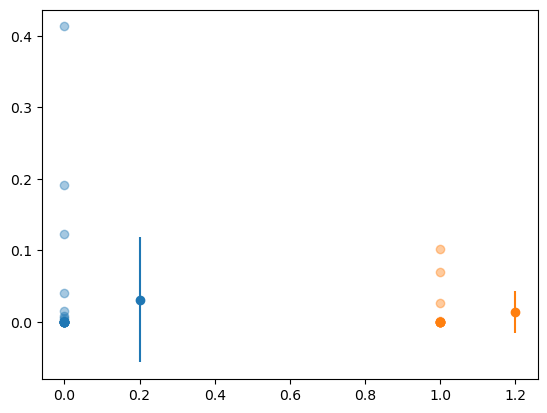

In [30]:
df_list = [chow_df, HFD_df]
param =   'sag_ratio'
fig, ax = plt.subplots()
counter = 0
for df in df_list:
    values = df[param].values
    markers = np.zeros(len(values)) + counter
    ax.scatter(markers, values, alpha=0.4)
    u = np.nanmean(values)
    sd = np.nanstd(values)
    ax.errorbar([counter+0.2], [u], yerr=sd, marker='o')

    counter += 1

plt.show()

In [15]:
u

np.float64(1.0)